# Project REXIA

# Image data

## Imports et préliminaires

In [112]:
import tensorflow
from tensorflow.keras.applications import inception_v3

from keras import preprocessing
import keras.applications
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import lime
from lime import lime_image
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
#import data
DATA_PATH = r"C:\Users\Asturiel\Documents\Cours\CentraleSupelec_COURS\Third_Year\REXIA\projet-rexia\rexia-responsible-explainable-ai-project\data\image_data"

In [114]:
df_attributes = pd.read_csv(str(DATA_PATH +  r"\list_attr_celeba.csv"))
df_bbox = pd.read_csv(str(DATA_PATH + r"\list_bbox_celeba.csv"))
df_eval_partitions = pd.read_csv(str(DATA_PATH + r"\list_eval_partition.csv"))
df_landmarks = pd.read_csv(str(DATA_PATH + r"\list_landmarks_align_celeba.csv"))

## Analyse du jeu de données

### Analyse descriptive

Data Files

- img_align_celeba.zip: All the face images, cropped and aligned 
list_eval_partition.csv: Recommended partitioning of images into training, validation, testing sets. Images 1-162770 are training, 162771-182637 are validation, 182638-202599 are testing 
- list_bbox_celeba.csv: Bounding box information for each image. "x_1" and "y_1" represent the upper left point coordinate of bounding box. "width" and "height" represent the width and height of bounding box
- list_landmarks_align_celeba.csv: Image landmarks and their respective coordinates. There are 5 landmarks: left eye, right eye, nose, left mouth, right mouth 
- list_attr_celeba.csv: Attribute labels for each image. There are 40 attributes. "1" represents positive while "-1" represents negative

In [133]:
print(df_attributes.shape)  # 202599 pictures and 41 attributes (including the image name) 
display(df_attributes.head())              
print(f"List of attributes : {df_attributes.columns.tolist()}")            
print("----------------------------------")
print("Number of positives per attribute:") 
display((df_attributes == 1).sum())
print("----------------------------------")
print(f"Average number of positives accrosss all attributes: {(df_attributes == 1).mean() } ")

(202599, 41)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


List of attributes : ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
----------------------------------
Number of positives per attribute:


image_id                    0
5_o_Clock_Shadow        22516
Arched_Eyebrows         54090
Attractive             103833
Bags_Under_Eyes         41446
Bald                     4547
Bangs                   30709
Big_Lips                48785
Big_Nose                47516
Black_Hair              48472
Blond_Hair              29983
Blurry                  10312
Brown_Hair              41572
Bushy_Eyebrows          28803
Chubby                  11663
Double_Chin              9459
Eyeglasses              13193
Goatee                  12716
Gray_Hair                8499
Heavy_Makeup            78390
High_Cheekbones         92189
Male                    84434
Mouth_Slightly_Open     97942
Mustache                 8417
Narrow_Eyes             23329
No_Beard               169158
Oval_Face               57567
Pale_Skin                8701
Pointy_Nose             56210
Receding_Hairline       16163
Rosy_Cheeks             13315
Sideburns               11449
Smiling                 97669
Straight_H

----------------------------------
Average number of positives accrosss all attributes: image_id               0.000000
5_o_Clock_Shadow       0.111136
Arched_Eyebrows        0.266981
Attractive             0.512505
Bags_Under_Eyes        0.204572
Bald                   0.022443
Bangs                  0.151575
Big_Lips               0.240796
Big_Nose               0.234532
Black_Hair             0.239251
Blond_Hair             0.147992
Blurry                 0.050899
Brown_Hair             0.205194
Bushy_Eyebrows         0.142168
Chubby                 0.057567
Double_Chin            0.046688
Eyeglasses             0.065119
Goatee                 0.062764
Gray_Hair              0.041950
Heavy_Makeup           0.386922
High_Cheekbones        0.455032
Male                   0.416754
Mouth_Slightly_Open    0.483428
Mustache               0.041545
Narrow_Eyes            0.115149
No_Beard               0.834940
Oval_Face              0.284143
Pale_Skin              0.042947
Pointy_Nose     

<Axes: ylabel='None'>

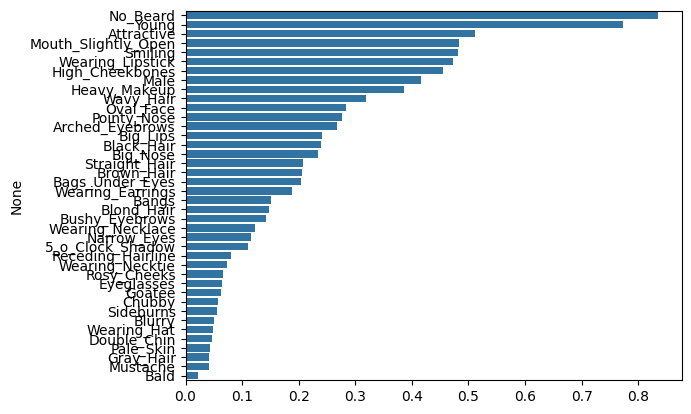

In [116]:
positive_rate = (df_attributes.drop('image_id', axis=1) == 1).mean().sort_values(ascending=False)
sns.barplot(x=positive_rate.values, y=positive_rate.index)

In [117]:
attr_cols = df_attributes.columns[1:]  # all columns except 'image_id'
df_eval_partitions['partition'].value_counts()    # 0=train, 1=val, 2=test
# puis merge avec les attributs pour vérifier que la distribution est homogène
merged = df_attributes.merge(df_eval_partitions, on='image_id')
merged.groupby('partition')[attr_cols].mean()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
partition,,,,,,,,,,,,,,,,,,,,,
0,-0.776654,-0.468231,0.027253,-0.591079,-0.954377,-0.696689,-0.518179,-0.528894,-0.521951,-0.701825,...,-0.887498,-0.040609,-0.582884,-0.361283,-0.626934,-0.901223,-0.060797,-0.757154,-0.853904,0.557879
1,-0.763930,-0.483163,0.040117,-0.585141,-0.958625,-0.706549,-0.693562,-0.502391,-0.582826,-0.692354,...,-0.862385,-0.033372,-0.588765,-0.446821,-0.618563,-0.905371,-0.108069,-0.758796,-0.854734,0.493129
2,-0.800220,-0.431119,-0.008316,-0.594730,-0.957619,-0.688508,-0.345957,-0.575994,-0.456768,-0.733494,...,-0.907224,0.000601,-0.580202,-0.271917,-0.586715,-0.915940,0.043783,-0.724176,-0.859834,0.514277


### Analyse des corrélations

<Axes: >

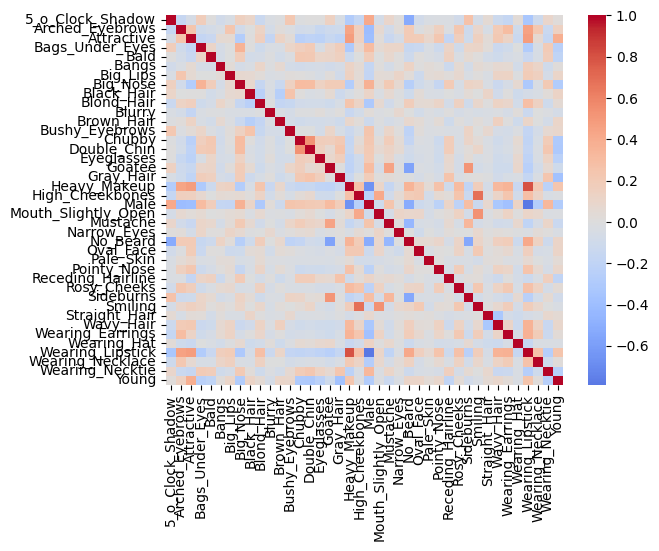

In [118]:
df_binary = (df_attributes[attr_cols] == 1).astype(int)
corr_matrix = df_binary.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)

In [119]:
# Extraire le triangle supérieur sans la diagonale
corr_pairs = (corr_matrix
              .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack()
              .sort_values(ascending=False))

corr_pairs.head(15)   # plus corrélées positivement
corr_pairs.tail(15)   # plus corrélées négativement

Double_Chin       Young              -0.309809
Straight_Hair     Wavy_Hair          -0.321452
Male              Wavy_Hair          -0.323983
5_o_Clock_Shadow  Wearing_Lipstick   -0.333921
Gray_Hair         Young              -0.364466
Male              Wearing_Earrings   -0.373469
Attractive        Male               -0.394451
Arched_Eyebrows   Male               -0.408016
Mustache          No_Beard           -0.452595
Male              No_Beard           -0.522243
5_o_Clock_Shadow  No_Beard           -0.526946
No_Beard          Sideburns          -0.543061
Goatee            No_Beard           -0.570071
Heavy_Makeup      Male               -0.666724
Male              Wearing_Lipstick   -0.789435
dtype: float64

#### Corrélations artificielles

Deux variables sont artificiellement corrélées quand leur forte corrélation statistique entre deux variables qui n'ont pas de lien causal directs mais résulte d'un troisième facteur.

**Wearing_Lipstick <-> Male** : forte corrélation négative, mais causée par le genre comme variable confondante - ce n'est pas que le rouge à lèvres cause d'être femme, c'est que les deux co-occurrent dans les données de collecte.

**Heavy_Makeup <-> Attractive** : corrélées positivement, mais le lien est biaisé par les standards de beauté présents dans les annotations humaines.

<Axes: >

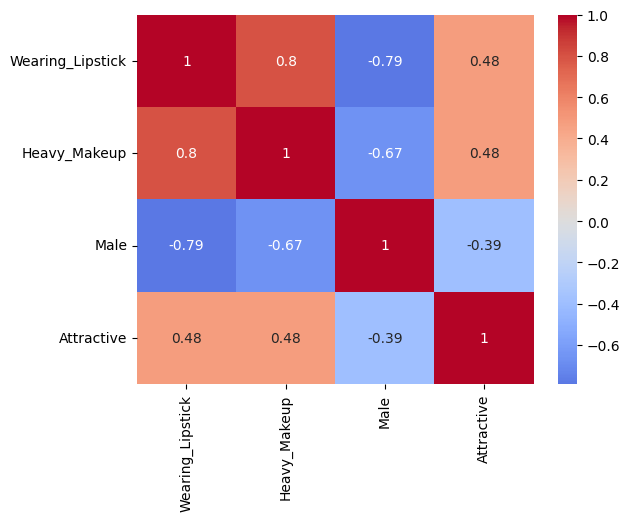

In [120]:
# tableau croisé
pd.crosstab(df_binary['Wearing_Lipstick'], df_binary['Male'], normalize='index')
# ou un heatmap de la sous-matrice
sns.heatmap(df_binary[['Wearing_Lipstick', 'Heavy_Makeup', 'Male', 'Attractive']].corr(),
            annot=True, cmap='coolwarm', center=0)

### Identification de variables sensibles

La justification de la sensibilité d'une variable repose sur trois critères : **caractéristique protégée** (genre, couleur de peau, âge = protégés par la loi en France/UE), **risque de discrimination** si utilisée dans un modèle, et **déséquilibre de représentation**. Par exemple Pale_Skin n'est pas directement un attribut légalement protégé mais il est un proxy de l'origine ethnique - ce qui le rend sensible.

In [121]:
sensitive = ['Male', 'Pale_Skin', 'Young']
(df_binary[sensitive] == 1).mean()   # taux de présence dans le dataset

Male         0.416754
Pale_Skin    0.042947
Young        0.773617
dtype: float64

### Analyse de disparité

Pale_Skin,0,1
Male,,
0,0.550447,0.032799
1,0.406606,0.010148


<Axes: >

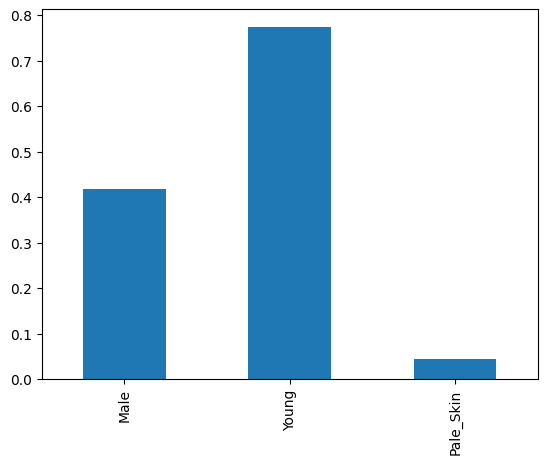

In [122]:
# Distribution de Male
df_binary['Male'].value_counts(normalize=True)

# Croisement de deux attributs sensibles
display(pd.crosstab(df_binary['Male'], df_binary['Pale_Skin'], normalize='all'))

group_cols = ['Male', 'Young', 'Pale_Skin']
df_binary[group_cols].mean().plot(kind='bar')

Le jeu de données présente plusieurs biais de représentativité :
- plus de 70% de personnes jeunes.
- 55% de femmes à la peau mate.


In [123]:
# Combinaisons rares
df_binary.groupby(['Male', 'Pale_Skin', 'Young']).size().sort_values()

Male  Pale_Skin  Young
1     1          0          483
0     1          0          739
1     1          1         1573
0     1          1         5906
      0          0        14139
1     0          0        30504
                 1        51874
0     0          1        97381
dtype: int64

### Analyse de la fairness

In [124]:
def fairness_metrics(df, sensitive_attr, target_attr) -> dict :
    groups = df.groupby(sensitive_attr)[target_attr].mean()
    # groups[1]  = P(Y=1 | S=1) 
    # groups[0]  = P(Y=1 | S=-1)  
    
    p_s1 = groups[1]  
    p_s0 = groups[0] #df_binary en entrée
    
    demographic_parity = abs(p_s1 - p_s0)
    disparate_impact   = p_s1 / p_s0 if p_s0 > 0 else np.nan
    
    return {"demographic_parity": float(demographic_parity), 
            "disparate_impact": float(disparate_impact)}
            #plus dellographic parity est proche de 0, plus target_attr est indépendant de sensitive_attr
            #plus cette valeur est grande, plus target_attr est indépendante de sensitive_attr
        

In [125]:
fairness_metrics(df_binary , "Pale_Skin", "Attractive")

{'demographic_parity': 0.21215639998086233,
 'disparate_impact': 1.4214523716894203}

In [126]:
fairness_metrics(df_binary , "Heavy_Makeup", "Attractive")

{'demographic_parity': 0.4896198630583009,
 'disparate_impact': 2.5155679111473197}

**Sensitive attribute**: Male

In [146]:
results = []
sensitive_attr_male = 'Male'
for attr in attr_cols:
    if attr == sensitive_attr_male:
        continue
    metrics = fairness_metrics(df_binary, sensitive_attr=sensitive_attr_male, target_attr=attr)
    metrics['attribute'] = attr
    
    results.append(metrics)

results_df_male = pd.DataFrame(results).sort_values('disparate_impact', ascending=False)

In [147]:
display(results_df_male)

,demographic_parity,disparate_impact,attribute
21,0.099626,3925.118278,Mustache
0,0.266264,1574.152498,5_o_Clock_Shadow
29,0.135374,1455.220829,Sideburns
16,0.150339,1367.522375,Goatee
37,0.173769,587.668138,Wearing_Necktie
4,0.053508,372.924380,Bald
14,0.088798,10.172032,Double_Chin
13,0.108890,9.935446,Chubby
17,0.074991,8.010561,Gray_Hair
15,0.101121,5.401073,Eyeglasses


traduis les standards de beauté : les femmes célèbres sont moins souvent chubby que les hommes célèbres

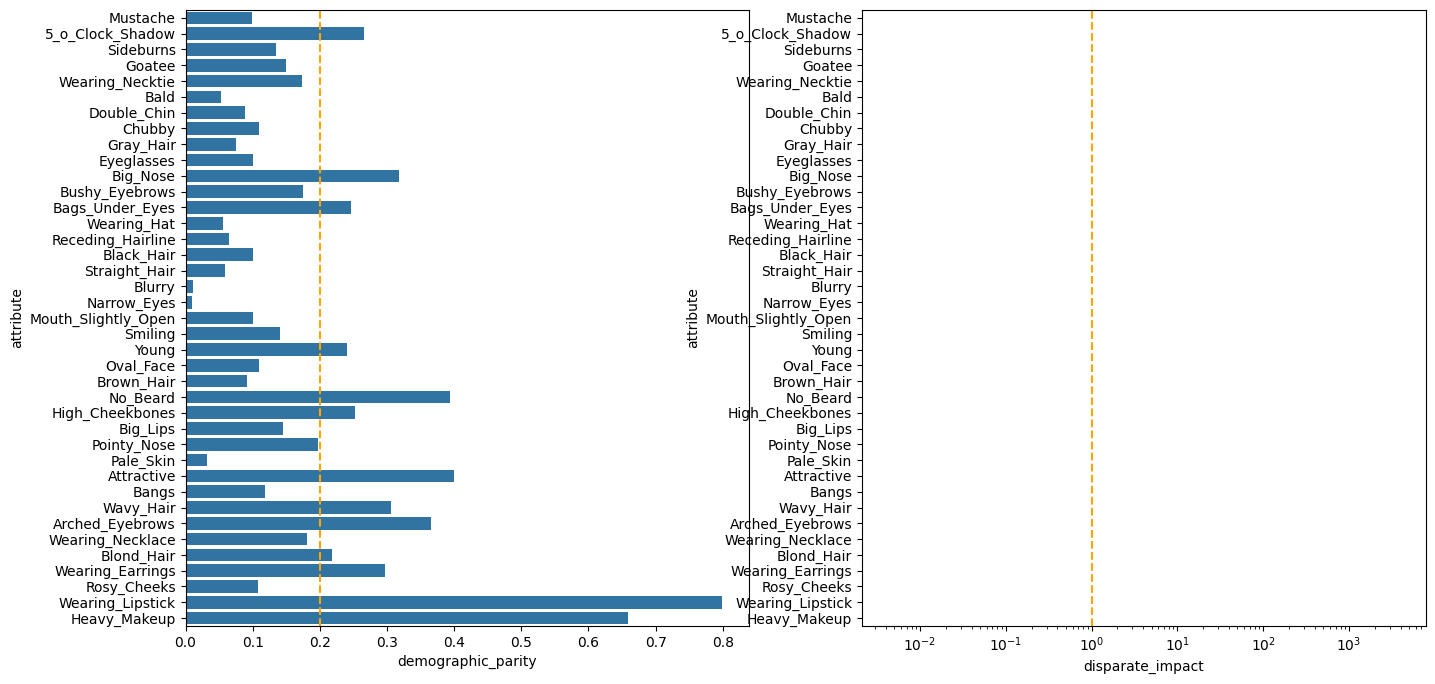

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(data=results_df_male, x='demographic_parity', y='attribute', ax=axes[0])
sns.barplot(data=results_df_male, x='disparate_impact',   y='attribute', ax=axes[1] )
axes[0].axvline(x=0, color='red', linestyle='--', label='Parity line')
axes[0].axvline(x=0.2, color='orange', linestyle='--', label='0.5 threshold')
axes[1].axvline(x=1, color='orange', linestyle='--', label='parity threshold')

**Sensitive attribute**: Pale skin

In [130]:
results = []
sensitive_attr = 'Pale_Skin'
for attr in attr_cols:
    if attr == sensitive_attr:
        continue
    metrics = fairness_metrics(df_binary, sensitive_attr=sensitive_attr, target_attr=attr)
    metrics['attribute'] = attr
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values('demographic_parity', ascending=False)

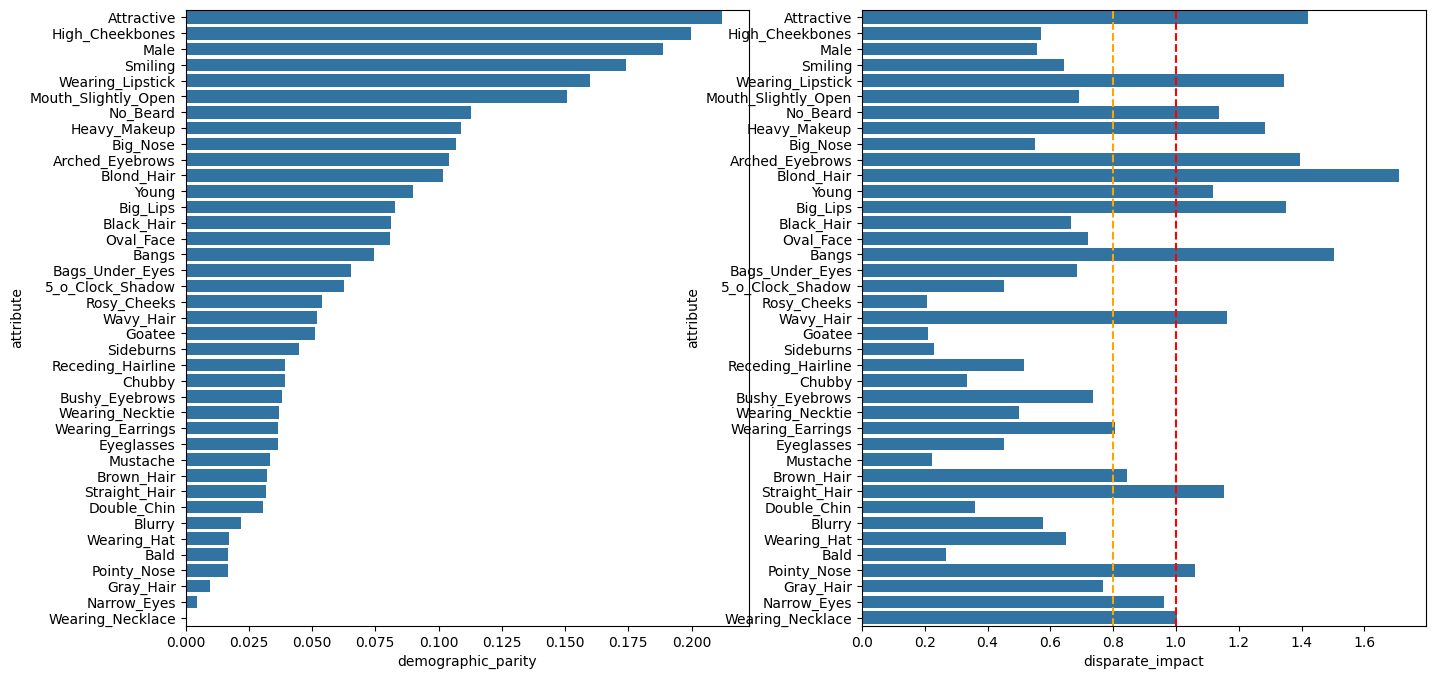

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(data=results_df, x='demographic_parity', y='attribute', ax=axes[0])
sns.barplot(data=results_df, x='disparate_impact',   y='attribute', ax=axes[1])
axes[0].axvline(x=1, color='orange', linestyle='--', label='parity threshold')

## Apprentissage automatique

### Pré-analyse

In [ ]:
print(f"Pourcentage of smiling pictures: {(df_attributes['Smiling'] == 1).mean() * 100:.2f}%")

Pourcentage of smiling pictures: 48.21%


Le dataset est équilibré, pas de traitement supplémentaire nécessaire.

In [142]:
results = []
sensitive_attr = 'Smiling'
for attr in attr_cols:
    if attr == sensitive_attr:
        continue
    metrics = fairness_metrics(df_binary, sensitive_attr=sensitive_attr, target_attr=attr)
    metrics['attribute'] = attr
    
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values('demographic_parity', ascending=False)
display(results_df)

,demographic_parity,disparate_impact,attribute
19,0.681164,6.378072,High_Cheekbones
21,0.536429,3.385972,Mouth_Slightly_Open
25,0.185769,1.954685,Oval_Face
35,0.181471,1.471413,Wearing_Lipstick
18,0.172161,1.566457,Heavy_Makeup
2,0.147894,1.335201,Attractive
20,0.136523,0.717091,Male
33,0.133378,2.070228,Wearing_Earrings
29,0.109600,9.506187,Rosy_Cheeks
3,0.091029,1.566498,Bags_Under_Eyes


In [137]:
df = df_attributes.merge(df_eval_partitions, on='image_id')
df['Smiling'] = (df['Smiling'] == 1).astype(int)
df_train = df[df['partition'] == 0]
df_eval = df[df['partition'] == 1]
df_test = df[df['partition'] == 2]

df_train.shape, df_eval.shape, df_test.shape

((162770, 42), (19867, 42), (19962, 42))

> 162k images

In [140]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory


train_ds = image_dataset_from_directory(
    r"C:\Users\Asturiel\Documents\Cours\CentraleSupelec_COURS\Third_Year\REXIA\projet-rexia\rexia-responsible-explainable-ai-project\data\image_data\img_align_celeba",
    image_size=(224, 224),
    batch_size=32
)


Found 184617 files belonging to 1 classes.


### Augmentation des données

In [ ]:

# Augmentation sur le train uniquement
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,        # pertinent pour des visages
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    df_train, directory='img_align_celeba/',
    x_col='image_id', y_col='Smiling',
    target_size=(64, 64),        # réduire pour aller plus vite
    batch_size=64,
    class_mode='raw'             # labels numériques directs
)

## Explications post-hoc

> Lime Shapley

In [ ]:
# Création de l'explainer LIME
limeExplainer = lime_image.LimeImageExplainer(
        
)

explanation = limeExplainer.explain_instance(
    image = imgs[0],
    classifier_fn=model.predict,
    top_labels=4,
    num_samples= 5)         

NameError: name 'imgs' is not defined